# Restoring operator pool from ADAPT.jl

Additional remarks about pauli operators from ADAPT team: https://github.com/kmsherbertvt/ADAPT.jl/blob/main/test/maxcut_qaoa.md

In [9]:
import json
from scipy import sparse
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
tqdm.pandas()

## Opening OP pool

In [3]:
op_pool_list = json.load(
    open(
        'ADAPT_pauli_ops/qaoa_double_pool_n12_list.json'
    )
)

In [4]:
op_pool_df = pd.DataFrame(op_pool_list)

In [5]:
op_pool_df['op_csc'] = op_pool_df.progress_apply(
    lambda x: sparse.csc_matrix(
        (
            x['nzval'],
            np.array(x['rowval']) - 1,
            np.array(x['colptr']) - 1
        )
    ),
    axis=1
)

100%|██████████████████████████████████████████████████████████████████████| 277/277 [00:00<00:00, 1510.52it/s]


In [6]:
op_pool_df

,nzval,m,colptr,rowval,op_index,pauli_string,op_csc
0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",4096,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13...",1,XIIIIIIIIIII,"(1, 0)\t1\n (0, 1)\t1\n (3, 2)\t1\n (2, 3..."
1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",4096,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[3, 4, 1, 2, 7, 8, 5, 6, 11, 12, 9, 10, 15, 16...",2,IXIIIIIIIIII,"(2, 0)\t1\n (3, 1)\t1\n (0, 2)\t1\n (1, 3..."
2,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",4096,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[5, 6, 7, 8, 1, 2, 3, 4, 13, 14, 15, 16, 9, 10...",3,IIXIIIIIIIII,"(4, 0)\t1\n (5, 1)\t1\n (6, 2)\t1\n (7, 3..."
3,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",4096,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[9, 10, 11, 12, 13, 14, 15, 16, 1, 2, 3, 4, 5,...",4,IIIXIIIIIIII,"(8, 0)\t1\n (9, 1)\t1\n (10, 2)\t1\n (11,..."
4,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",4096,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 2...",5,IIIIXIIIIIII,"(16, 0)\t1\n (17, 1)\t1\n (18, 2)\t1\n (1..."
...,...,...,...,...,...,...,...
272,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -...",4096,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[2049, 2050, 2051, 2052, 2053, 2054, 2055, 205...",273,IIIIIIIIIZIy,"(2048, 0)\t-1\n (2049, 1)\t-1\n (2050, 2)\..."
273,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",4096,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[3073, 3074, 3075, 3076, 3077, 3078, 3079, 308...",274,IIIIIIIIIIXX,"(3072, 0)\t1\n (3073, 1)\t1\n (3074, 2)\t1..."
274,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",4096,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[3073, 3074, 3075, 3076, 3077, 3078, 3079, 308...",275,IIIIIIIIIIyy,"(3072, 0)\t1\n (3073, 1)\t1\n (3074, 2)\t1..."
275,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -...",4096,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1025, 1026, 1027, 1028, 1029, 1030, 1031, 103...",276,IIIIIIIIIIyZ,"(1024, 0)\t-1\n (1025, 1)\t-1\n (1026, 2)\..."


## OP visualization

In [7]:
op_pool_df['op_csc'][0]

<4096x4096 sparse matrix of type '<class 'numpy.int64'>'
	with 4096 stored elements in Compressed Sparse Column format>

In [8]:
op_pool_df['op_csc'][20]

<4096x4096 sparse matrix of type '<class 'numpy.int64'>'
	with 4096 stored elements in Compressed Sparse Column format>

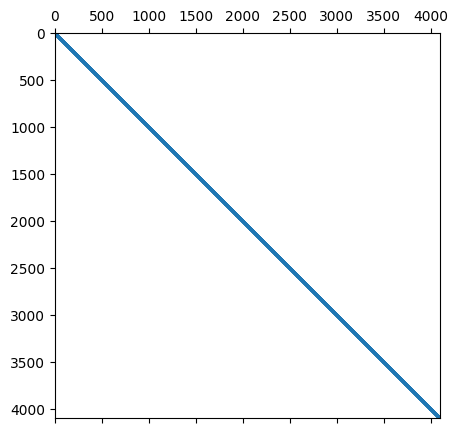

In [12]:
plt.figure(figsize=(5, 5))
plt.spy(op_pool_df['op_csc'][0], markersize=1)  # markersize controls the size of dots

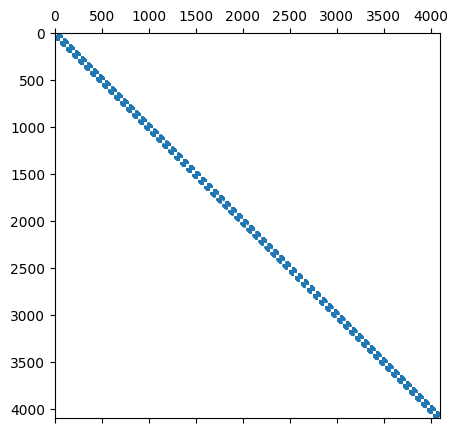

In [13]:
plt.figure(figsize=(5, 5))
plt.spy(op_pool_df['op_csc'][30], markersize=1)  # markersize controls the size of dots

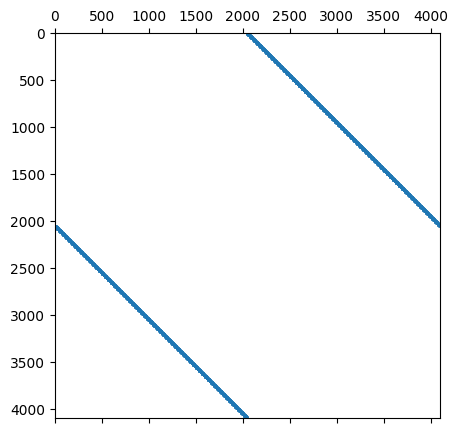

In [14]:
plt.figure(figsize=(5, 5))
plt.spy(op_pool_df['op_csc'][129], markersize=1)  # markersize controls the size of dots

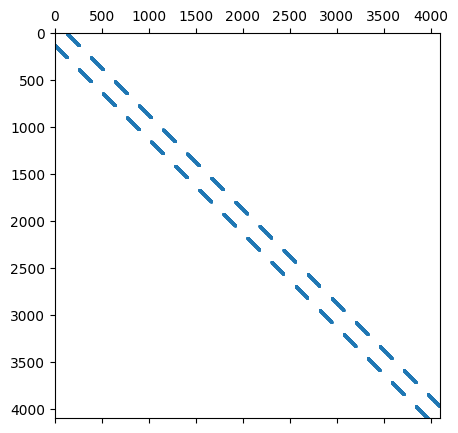

In [15]:
plt.figure(figsize=(5, 5))
plt.spy(op_pool_df['op_csc'][220], markersize=1)  # markersize controls the size of dots